# Residual Policy Evaluation and Comparison

This notebook loads trained residual policies and compares their performance to:
1. Pure pretrained BC policies
2. Pure pretrained Diffusion policies
3. Residual-augmented versions of both

The evaluation focuses on recovery performance under perturbations.

In [1]:
import os
import sys
import h5py
import torch
import numpy as np
import json
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from base64 import b64encode
from IPython.display import HTML, display
import imageio.v2 as imageio

# Ensure local packages are importable
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'src')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..', 'robomimic', 'robomimic')))

from a2l_pr.models import GatedResidualRecoveryPolicy, ResidualRecoveryPolicy
from a2l_pr.adapters.robomimic import RobomimicAdapter
from a2l_pr.perturbations.generator import PerturbationGenerator, PerturbationType

import robomimic.utils.file_utils as FileUtils
import robomimic.utils.env_utils as EnvUtils
import robomimic.utils.obs_utils as ObsUtils
from robomimic.algo import RolloutPolicy
from robomimic.envs.env_base import EnvBase

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'CUDA Available: {torch.cuda.is_available()}')


I0000 00:00:1779340357.923530  836517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779340357.947309  836517 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1779340358.609744  836517 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Device: cuda
CUDA Available: True


## Setup: Data Paths and Configuration

In [2]:
# Base paths
WORKSPACE_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
ROBOMIMIC_ROOT = os.path.join(WORKSPACE_ROOT, 'robomimic', 'robomimic')

# Dataset path
DATASET_PATH = os.path.join(ROBOMIMIC_ROOT, 'datasets', 'square', 'ph', 'low_dim_v15.hdf5')

# Trained model paths
BC_MODEL_DIR = os.path.join(ROBOMIMIC_ROOT, 'bc_trained_models', 'test')
DIFFUSION_MODEL_DIR = os.path.join(ROBOMIMIC_ROOT, 'diffusion_policy_trained_models', 'test')

# Residual policy checkpoint - update this to your trained residual policy path
RESIDUAL_CHECKPOINT = os.path.join(os.getcwd(), 'gated_residual_recovery_policy.pth')

print(f'Dataset path: {DATASET_PATH}')
print(f'BC model dir: {BC_MODEL_DIR}')
print(f'Diffusion model dir: {DIFFUSION_MODEL_DIR}')
print(f'Residual policy: {RESIDUAL_CHECKPOINT}')
print(f'Dataset exists: {os.path.exists(DATASET_PATH)}')
print(f'BC model dir exists: {os.path.exists(BC_MODEL_DIR)}')
print(f'Diffusion model dir exists: {os.path.exists(DIFFUSION_MODEL_DIR)}')
print(f'Residual policy exists: {os.path.exists(RESIDUAL_CHECKPOINT)}')


Dataset path: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/datasets/square/ph/low_dim_v15.hdf5
BC model dir: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/bc_trained_models/test
Diffusion model dir: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/diffusion_policy_trained_models/test
Residual policy: /home/griffing52/vail/bot2bot/bot2bot/a2l/a2l-pr/notebooks/gated_residual_recovery_policy.pth
Dataset exists: True
BC model dir exists: True
Diffusion model dir exists: True
Residual policy exists: True


## Utility Functions

In [3]:
def load_robomimic_trajectory(hdf5_path, demo_key='demo_0'):
    """Load a single trajectory from robomimic HDF5 file."""
    if not os.path.exists(hdf5_path):
        raise FileNotFoundError(f"Dataset not found: {hdf5_path}")
    
    with h5py.File(hdf5_path, 'r') as f:
        if 'data' not in f or demo_key not in f['data']:
            raise KeyError(f"Demo {demo_key} not found in dataset")
        
        demo_grp = f['data'][demo_key]
        obs_grp = demo_grp['obs']
        
        trajectory = {
            'actions': demo_grp['actions'][:],
            'observations': {}
        }
        
        for key in obs_grp.keys():
            trajectory['observations'][key] = obs_grp[key][:]
    
    return trajectory


def _traj_length(traj):
    """Get trajectory length."""
    return len(traj['actions'])


def get_trajectory_demos(hdf5_path, limit=None):
    """Get list of available demos in dataset."""
    with h5py.File(hdf5_path, 'r') as f:
        demos = list(f['data'].keys())
    
    if limit:
        demos = demos[:limit]
    return demos

## Load Pretrained Policies

The following code loads the trained BC and Diffusion policies from your model checkpoints. 

**Notes:**
- Policies are automatically loaded from the latest checkpoint in each model directory
- BC and Diffusion policies are wrapped with `RolloutPolicy` for environment interaction
- If a checkpoint is missing, that policy evaluation will be skipped

In [4]:
def find_latest_model_dir(model_base_dir):
    """Find the most recent model directory by timestamp."""
    if not os.path.exists(model_base_dir):
        return None
    
    subdirs = [d for d in os.listdir(model_base_dir) if os.path.isdir(os.path.join(model_base_dir, d))]
    if not subdirs:
        return None
    
    # Sort by name (assuming timestamp format)
    subdirs.sort(reverse=True)
    return os.path.join(model_base_dir, subdirs[0])


def load_pretrained_policy(checkpoint_path, device='cpu'):
    """Load a pretrained robomimic policy from checkpoint."""
    if not os.path.exists(checkpoint_path):
        print(f"Checkpoint not found: {checkpoint_path}")
        return None
    
    try:
        policy, ckpt_dict = FileUtils.policy_from_checkpoint(
            device=device,
            ckpt_path=checkpoint_path,
            verbose=False
        )
        return policy
    except Exception as e:
        print(f"Error loading policy from {checkpoint_path}: {e}")
        return None


# Find and load BC policy
bc_model_dir = find_latest_model_dir(BC_MODEL_DIR)
if bc_model_dir:
    bc_models_dir = os.path.join(bc_model_dir, 'models')
    bc_checkpoints = sorted([f for f in os.listdir(bc_models_dir) if f.endswith('.pth')])
    if bc_checkpoints:
        bc_checkpoint = os.path.join(bc_models_dir, bc_checkpoints[-1])  # Latest checkpoint
        print(f"Loading BC policy from: {bc_checkpoint}")
        bc_policy = load_pretrained_policy(bc_checkpoint, device=device)
        if bc_policy:
            print("✓ BC policy loaded successfully")
    else:
        print("No BC checkpoints found")
        bc_policy = None
else:
    print("No BC model directory found")
    bc_policy = None

# Find and load Diffusion policy
diffusion_model_dir = find_latest_model_dir(DIFFUSION_MODEL_DIR)
if diffusion_model_dir:
    diffusion_models_dir = os.path.join(diffusion_model_dir, 'models')
    diffusion_checkpoints = sorted([f for f in os.listdir(diffusion_models_dir) if f.endswith('.pth')])
    if diffusion_checkpoints:
        diffusion_checkpoint = os.path.join(diffusion_models_dir, diffusion_checkpoints[-1])  # Latest checkpoint
        print(f"Loading Diffusion policy from: {diffusion_checkpoint}")
        diffusion_policy = load_pretrained_policy(diffusion_checkpoint, device=device)
        if diffusion_policy:
            print("✓ Diffusion policy loaded successfully")
    else:
        print("No Diffusion checkpoints found")
        diffusion_policy = None
else:
    print("No Diffusion model directory found")
    diffusion_policy = None

Loading BC policy from: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/bc_trained_models/test/20260511234956/models/model_epoch_950.pth

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'robot0_eef_quat', 'object', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []
✓ BC policy loaded successfully
Loading Diffusion policy from: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/diffusion_policy_trained_models/test/20260512010513/models/model_epoch_950.pth

============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['robot0_eef_pos', 'robot0_eef_quat', 'object', 'robot0_gripper_qpos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


number of parameters: 6.587828e+07
✓ Diffusion policy loaded successfully


## Load Trained Residual Policies

**IMPORTANT:** Update the checkpoint paths below to point to your trained residual policies.

The residual policy is a neural network that learns to predict corrective actions:
- **Input**: Past states and actions (history) + current state before perturbation
- **Output**: Residual actions for the next horizon steps
- **Goal**: Predict actions that would undo/recover from perturbations

If you haven't trained residual policies yet, you can skip this and the notebook will still evaluate the base policies.

In [5]:
def load_residual_policy(checkpoint_path, device='cpu'):
    """Load a trained gated residual recovery policy."""
    if not os.path.exists(checkpoint_path):
        print(f"Residual policy checkpoint not found: {checkpoint_path}")
        return None

    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        if not isinstance(checkpoint, dict) or checkpoint.get('model_class') != 'GatedResidualRecoveryPolicy':
            raise ValueError(
                "Expected a GatedResidualRecoveryPolicy checkpoint dict. "
                "Rerun robomimic_residual_training.ipynb after the gated update."
            )

        state_dim = int(checkpoint['state_dim'])
        action_dim = int(checkpoint['action_dim'])
        history_length = int(checkpoint.get('history_length', 12))
        horizon = int(checkpoint.get('prediction_horizon', 30))
        num_failure_types = int(checkpoint.get('num_failure_types', 5))

        print("Loading gated residual policy:")
        print(f"  state_dim={state_dim}, action_dim={action_dim}")
        print(f"  history_length={history_length}, horizon={horizon}")
        print(f"  num_failure_types={num_failure_types}")

        policy = GatedResidualRecoveryPolicy(
            state_dim=state_dim,
            action_dim=action_dim,
            history_length=history_length,
            prediction_horizon=horizon,
            num_failure_types=num_failure_types,
        ).to(device)
        policy.load_state_dict(checkpoint['model_state_dict'])
        policy.eval()
        policy.checkpoint_metadata = checkpoint

        print("✓ Gated residual policy loaded successfully")
        return policy

    except Exception as e:
        print(f"✗ Error loading residual policy: {e}")
        import traceback
        traceback.print_exc()
        return None


# Try to load residual policy
residual_policy = load_residual_policy(RESIDUAL_CHECKPOINT, device=device)
if residual_policy:
    print("✓ Gated residual policy ready for composition")
else:
    print("⚠ Gated residual policy not available")


Loading gated residual policy:
  state_dim=23, action_dim=7
  history_length=12, horizon=30
  num_failure_types=5
✓ Gated residual policy loaded successfully
✓ Gated residual policy ready for composition


In [6]:
# Verify gated residual policy dimensions match checkpoint metadata.
if residual_policy:
    print("\n--- Gated Residual Policy Verification ---")
    ckpt = getattr(residual_policy, 'checkpoint_metadata', {})
    print(f"Checkpoint class: {ckpt.get('model_class')}")
    print(f"Failure mapping: {ckpt.get('failure_type_to_id')}")

    step_enc_weight = residual_policy.state_dict()['step_encoder.0.weight']
    hidden_dim, input_dim = step_enc_weight.shape
    print(f"Step encoder input: {input_dim} dims, hidden: {hidden_dim}")
    print(f"Expected: state({residual_policy.state_dim}) + action({residual_policy.action_dim}) = {residual_policy.state_dim + residual_policy.action_dim}")
    print(f"Match: {input_dim == residual_policy.state_dim + residual_policy.action_dim}")

    try:
        dummy_states = torch.randn(1, residual_policy.history_length, residual_policy.state_dim).to(device)
        dummy_actions = torch.randn(1, residual_policy.history_length, residual_policy.action_dim).to(device)
        with torch.no_grad():
            output = residual_policy.predict_first_step(dummy_states, dummy_actions)
        print("\nTest forward pass:")
        print(f"  residual: {output['residuals'].shape}")
        print(f"  gate_prob: {output['gate_probs'].shape} value={float(output['gate_probs'][0]):.4f}")
        print(f"  failure_logits: {output['failure_logits'].shape}")
        print("  ✓ Dimensions are compatible!")
    except Exception as e:
        print(f"  ✗ Forward pass failed: {e}")



--- Gated Residual Policy Verification ---
Checkpoint class: GatedResidualRecoveryPolicy
Failure mapping: {'no_failure': 0, 'underreach_idle_before_max_reach': 1, 'premature_gripper_close': 2, 'lateral_drift': 3, 'premature_gripper_open': 4}
Step encoder input: 30 dims, hidden: 128
Expected: state(23) + action(7) = 30
Match: True

Test forward pass:
  residual: torch.Size([1, 7])
  gate_prob: torch.Size([1]) value=0.2140
  failure_logits: torch.Size([1, 5])
  ✓ Dimensions are compatible!


## Policy Evaluation Functions

In [7]:
def extract_state_from_obs(obs_dict, t):
    """Extract state vector from observation dictionary."""
    state_keys = [
        'robot0_eef_pos',
        'robot0_eef_quat',
        'robot0_gripper_qpos',
        'robot0_joint_pos',
        'robot0_joint_vel',
    ]

    state_parts = []
    for key in state_keys:
        if key in obs_dict and t < len(obs_dict[key]):
            val = np.asarray(obs_dict[key][t]).reshape(-1).astype(np.float32)
            state_parts.append(val)

    if state_parts:
        return np.concatenate(state_parts)
    return None


class GatedComposedPolicy:
    """Wraps a base policy with gated residual corrections."""

    def __init__(
        self,
        base_policy,
        residual_policy,
        device='cpu',
        residual_weight=0.1,
        clamp_residual=0.1,
        gate_threshold=0.7,
    ):
        self.base_policy = base_policy
        self.residual_policy = residual_policy
        self.device = device
        self.residual_weight = residual_weight
        self.clamp_residual = clamp_residual
        self.gate_threshold = gate_threshold
        self.history_length = int(getattr(residual_policy, 'history_length', 12))
        self.state_history = []
        self.action_history = []
        metadata = getattr(residual_policy, 'checkpoint_metadata', {}) if residual_policy is not None else {}
        mapping = metadata.get('failure_type_to_id', {}) or {}
        self.failure_id_to_type = {int(v): str(k) for k, v in mapping.items()}
        if not self.failure_id_to_type:
            self.failure_id_to_type = {0: 'no_failure'}
        self.reset_diagnostics()

    def reset_diagnostics(self):
        self.gate_probs = []
        self.residual_norms = []
        self.interventions = 0
        self.ready_steps = 0
        self.action_step = 0
        self.diag_steps = []
        self.failure_type_ids = []
        self.failure_type_names = []
        self.failure_confidences = []
        self.applied_interventions = []

    def reset(self):
        self.state_history = []
        self.action_history = []
        self.reset_diagnostics()
        if hasattr(self.base_policy, 'start_episode'):
            self.base_policy.start_episode()
        elif hasattr(self.base_policy, 'reset'):
            self.base_policy.reset()

    def start_episode(self):
        self.reset()

    def _extract_state(self, obs):
        state_keys = [
            'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos',
            'robot0_joint_pos', 'robot0_joint_vel'
        ]
        state_parts = []
        for key in state_keys:
            if key in obs:
                state_parts.append(np.asarray(obs[key]).reshape(-1).astype(np.float32))
        if state_parts:
            return np.concatenate(state_parts)
        return None

    def get_diagnostics(self):
        return {
            'ready_steps': self.ready_steps,
            'interventions': self.interventions,
            'mean_gate_prob': float(np.mean(self.gate_probs)) if self.gate_probs else 0.0,
            'max_gate_prob': float(np.max(self.gate_probs)) if self.gate_probs else 0.0,
            'mean_residual_norm': float(np.mean(self.residual_norms)) if self.residual_norms else 0.0,
            'max_residual_norm': float(np.max(self.residual_norms)) if self.residual_norms else 0.0,
            'steps': list(self.diag_steps),
            'gate_probs': list(self.gate_probs),
            'residual_norms': list(self.residual_norms),
            'failure_type_ids': list(self.failure_type_ids),
            'failure_type_names': list(self.failure_type_names),
            'failure_confidences': list(self.failure_confidences),
            'applied_interventions': list(self.applied_interventions),
            'gate_threshold': float(self.gate_threshold),
        }

    def __call__(self, obs):
        base_action = self.base_policy(obs)
        if isinstance(base_action, torch.Tensor):
            base_action = base_action.detach().cpu().numpy()
        base_action = np.asarray(base_action).reshape(-1).astype(np.float32)
        current_step = self.action_step
        self.action_step += 1

        state = self._extract_state(obs)
        if state is None or self.residual_policy is None:
            return base_action

        self.state_history.append(state)
        self.action_history.append(base_action.copy())
        if len(self.state_history) > self.history_length:
            self.state_history = self.state_history[-self.history_length:]
            self.action_history = self.action_history[-self.history_length:]

        if len(self.state_history) < self.history_length:
            return base_action

        self.ready_steps += 1
        try:
            past_states = torch.tensor(np.stack(self.state_history[-self.history_length:]), dtype=torch.float32, device=self.device).unsqueeze(0)
            past_actions = torch.tensor(np.stack(self.action_history[-self.history_length:]), dtype=torch.float32, device=self.device).unsqueeze(0)
            with torch.no_grad():
                output = self.residual_policy.predict_first_step(past_states, past_actions)

            gate_prob = float(output['gate_probs'][0].detach().cpu().item())
            residual = output['residuals'][0].detach().cpu().numpy()
            residual = np.clip(residual, -self.clamp_residual, self.clamp_residual)
            residual_norm = float(np.linalg.norm(residual))
            failure_probs = torch.softmax(output['failure_logits'][0], dim=-1).detach().cpu().numpy()
            failure_type_id = int(np.argmax(failure_probs))
            failure_confidence = float(failure_probs[failure_type_id])
            failure_type_name = self.failure_id_to_type.get(failure_type_id, f'failure_{failure_type_id}')
            applied = bool(gate_prob >= self.gate_threshold)

            self.diag_steps.append(int(current_step))
            self.gate_probs.append(gate_prob)
            self.residual_norms.append(residual_norm)
            self.failure_type_ids.append(failure_type_id)
            self.failure_type_names.append(failure_type_name)
            self.failure_confidences.append(failure_confidence)
            self.applied_interventions.append(applied)

            if applied:
                self.interventions += 1
                return base_action + self.residual_weight * gate_prob * residual
        except Exception as e:
            if len(self.gate_probs) == 0:
                print(f"Gated residual inference failed once; falling back to base action: {e}")

        return base_action


# Backward-compatible alias for later cells that still refer to ComposedPolicy.
ComposedPolicy = GatedComposedPolicy



def _render_frame(env, camera_name='agentview', height=256, width=256):
    try:
        return env.render(mode='rgb_array', height=height, width=width, camera_name=camera_name)
    except TypeError:
        try:
            return env.render(mode='rgb_array', height=height, width=width)
        except TypeError:
            return env.render(mode='rgb_array')
    except Exception as e:
        print(f"Video render failed: {e}")
        return None


def run_rollout_with_trajectory(
    policy,
    env,
    horizon=400,
    record_obs_keys=None,
    video_path=None,
    video_fps=20,
    video_every=2,
    video_camera='agentview',
    video_height=256,
    video_width=256,
):
    """Run policy rollout, optionally recording an MP4 from sim rendering."""
    if record_obs_keys is None:
        record_obs_keys = ['robot0_eef_pos', 'robot0_gripper_qpos', 'robot0_joint_pos']

    obs = env.reset()
    if hasattr(policy, 'start_episode'):
        policy.start_episode()
    elif hasattr(policy, 'reset'):
        policy.reset()

    writer = None
    if video_path is not None:
        video_path = Path(video_path)
        video_path.parent.mkdir(parents=True, exist_ok=True)
        writer = imageio.get_writer(str(video_path), fps=video_fps)
        frame = _render_frame(env, camera_name=video_camera, height=video_height, width=video_width)
        if frame is not None:
            writer.append_data(frame)

    done = False
    total_reward = 0.0
    step = 0
    trajectory = []
    info = {}

    try:
        while not done and step < horizon:
            action = policy(obs)
            obs, reward, done, info = env.step(action)
            total_reward += reward
            step += 1

            if writer is not None and step % video_every == 0:
                frame = _render_frame(env, camera_name=video_camera, height=video_height, width=video_width)
                if frame is not None:
                    writer.append_data(frame)

            trajectory.append({
                'action': action.copy() if isinstance(action, np.ndarray) else action,
                'reward': reward,
                'obs': {k: obs[k].copy() if isinstance(obs[k], np.ndarray) else obs[k] for k in record_obs_keys if k in obs}
            })
    finally:
        if writer is not None:
            writer.close()

    success = info.get('success', False) if isinstance(info, dict) else False
    return {
        'total_reward': total_reward,
        'trajectory': trajectory,
        'success': success,
        'num_steps': len(trajectory),
        'video_path': str(video_path) if video_path is not None else None,
    }


## Composed Policy & Trajectory Recording

This section creates a composed policy that wraps BC + residual correction and runs rollouts while recording trajectories for visualization.

**Control Flow:**
1. Base policy (BC) predicts action
2. Residual policy predicts correction based on history
3. Executed action = base_action + clipped(residual_correction)
4. Full trajectory recorded for comparison


In [8]:
# Setup environment and rollout utilities
import robomimic.utils.env_utils as EnvUtils
import robomimic.utils.obs_utils as ObsUtils
from robomimic.envs.env_base import EnvBase

def get_checkpoint_info(checkpoint_path):
    """Get environment metadata from a checkpoint."""
    try:
        ckpt_dict = FileUtils.maybe_dict_from_checkpoint(ckpt_path=checkpoint_path)
        return ckpt_dict
    except Exception as e:
        print(f"Error loading checkpoint info: {e}")
        return None

def create_env_for_rollout(checkpoint_path):
    """Create environment from checkpoint for policy rollouts."""
    try:
        ckpt_dict = FileUtils.maybe_dict_from_checkpoint(ckpt_path=checkpoint_path)
        env_meta = ckpt_dict.get('env_metadata')
        
        if env_meta is None:
            print(f"No environment metadata in checkpoint")
            return None
        
        # Initialize observation utilities
        obs_spec = ckpt_dict.get('obs_spec')
        if obs_spec:
            ObsUtils.initialize_obs_utils_with_obs_specs(obs_modality_specs=obs_spec)
        
        # Create environment
        env = EnvUtils.create_env_from_metadata(env_meta=env_meta, render=False, render_offscreen=True)
        return env
    except Exception as e:
        print(f"Error creating environment: {e}")
        return None

def run_rollout(policy, env, horizon=400, num_rollouts=3, render=False):
    """Run policy in environment and collect returns.
    
    Returns:
        list: Returns for each rollout
    """
    if env is None or policy is None:
        return []
    
    returns = []
    
    try:
        for rollout_idx in range(num_rollouts):
            obs = env.reset()
            done = False
            total_reward = 0.0
            step = 0
            
            while not done and step < horizon:
                # Get action from policy
                action = policy(obs)
                
                # Take environment step
                obs, reward, done, info = env.step(action)
                total_reward += reward
                step += 1
            
            returns.append(total_reward)
            print(f"  Rollout {rollout_idx+1}/{num_rollouts}: Return = {total_reward:.4f}")
    
    except Exception as e:
        print(f"Error during rollout: {e}")
    
    return returns

# Get test trajectories
print(f"Loading dataset from {DATASET_PATH}")
try:
    test_demos = get_trajectory_demos(DATASET_PATH, limit=5)  # Evaluate on 5 trajectories
    print(f"Found {len(test_demos)} test trajectories for recovery evaluation")
except Exception as e:
    print(f"Error loading test trajectories: {e}")
    test_demos = []


Loading dataset from /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/datasets/square/ph/low_dim_v15.hdf5
Found 5 test trajectories for recovery evaluation


In [9]:
# Benchmark: BC Policy vs BC + Gated Residual Policy
results = {
    'bc_only': {
        'returns': [],
        'trajectories': [],
        'successes': 0,
        'videos': [],
    },
    'bc_residual': {
        'returns': [],
        'trajectories': [],
        'successes': 0,
        'diagnostics': [],
        'videos': [],
    }
}

print("\n" + "="*70)
print("BENCHMARK: BC Policy vs BC + Gated Residual Policy")
print("="*70)

if bc_policy is not None and 'bc_checkpoint' in locals():
    print(f"\nLoading BC checkpoint: {bc_checkpoint}")
    env = create_env_for_rollout(bc_checkpoint)
    if env:
        print("✓ Environment created successfully")

        video_dir = Path(os.getcwd()) / 'evaluation_videos'
        print(f"Videos will be saved to: {video_dir}")

        print("\n--- Running BC Policy Only ---")
        num_rollouts = 8
        for rollout_idx in range(num_rollouts):
            print(f"Rollout {rollout_idx+1}/{num_rollouts}...", end=" ")
            video_path = video_dir / f'bc_only_rollout_{rollout_idx + 1}.mp4' if rollout_idx < 2 else None
            result = run_rollout_with_trajectory(bc_policy, env, horizon=400, video_path=video_path)
            results['bc_only']['returns'].append(result['total_reward'])
            results['bc_only']['trajectories'].append(result['trajectory'])
            if result.get('video_path'):
                results['bc_only']['videos'].append(result['video_path'])
            if result['success']:
                results['bc_only']['successes'] += 1
            print(f"Return: {result['total_reward']:.4f}, Success: {result['success']}")

        if residual_policy is not None:
            print("\n--- Running BC + Gated Residual Policy ---")
            composed_policy = GatedComposedPolicy(
                bc_policy,
                residual_policy,
                device=device,
                residual_weight=0.1,
                clamp_residual=0.1,
                gate_threshold=0.7,
            )

            for rollout_idx in range(num_rollouts):
                print(f"Rollout {rollout_idx+1}/{num_rollouts}...", end=" ")
                video_path = video_dir / f'bc_gated_residual_rollout_{rollout_idx + 1}.mp4' if rollout_idx < 2 else None
                result = run_rollout_with_trajectory(composed_policy, env, horizon=400, video_path=video_path)
                diagnostics = composed_policy.get_diagnostics()
                results['bc_residual']['returns'].append(result['total_reward'])
                results['bc_residual']['trajectories'].append(result['trajectory'])
                results['bc_residual']['diagnostics'].append(diagnostics)
                if result.get('video_path'):
                    results['bc_residual']['videos'].append(result['video_path'])
                if result['success']:
                    results['bc_residual']['successes'] += 1
                print(
                    f"Return: {result['total_reward']:.4f}, Success: {result['success']}, "
                    f"Interventions: {diagnostics['interventions']}, "
                    f"Mean gate: {diagnostics['mean_gate_prob']:.4f}, "
                    f"Mean |res|: {diagnostics['mean_residual_norm']:.4f}"
                )
        else:
            print("\n⚠ Gated residual policy not available - skipping BC+Residual evaluation")
    else:
        print("✗ Failed to create environment")
elif bc_policy is None:
    print("✗ BC policy not loaded")
else:
    print("✗ BC checkpoint not found")

print("\n✓ Evaluation complete!")


# Embed the first saved videos directly in the notebook for quick visual comparison.
def _video_html(video_path, title, width=360):
    if not video_path or not os.path.exists(video_path):
        return f"<div><h3>{title}</h3><p>Video not available.</p></div>"
    data = b64encode(open(video_path, 'rb').read()).decode('ascii')
    return f"""
    <div style='text-align:center; margin: 8px;'>
      <h3>{title}</h3>
      <video width='{width}' controls loop>
        <source src='data:video/mp4;base64,{data}' type='video/mp4'>
      </video>
      <div style='font-family:monospace; font-size:12px;'>{video_path}</div>
    </div>
    """

video_blocks = []
if results['bc_only'].get('videos'):
    video_blocks.append(_video_html(results['bc_only']['videos'][0], 'BC Policy Only'))
if results['bc_residual'].get('videos'):
    video_blocks.append(_video_html(results['bc_residual']['videos'][0], 'BC + Gated Residual'))

if video_blocks:
    display(HTML("<div style='display:flex; flex-wrap:wrap; gap:16px;'>" + "".join(video_blocks) + "</div>"))
else:
    print('No rollout videos were recorded.')


[robosuite WARNING] No private macro file found! (macros.py:53)


[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)


[robosuite WARNING] To setup, run: python /home/griffing52/miniconda3/envs/a2l/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)



BENCHMARK: BC Policy vs BC + Gated Residual Policy

Loading BC checkpoint: /home/griffing52/vail/bot2bot/bot2bot/a2l/robomimic/robomimic/bc_trained_models/test/20260511234956/models/model_epoch_950.pth


[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)


...

Return: 0.0000, Success: False, Interventions: 0, Mean gate: 0.3691, Mean |res|: 0.1683
Rollout 5/8... 

Return: 0.0000, Success: False, Interventions: 40, Mean gate: 0.4277, Mean |res|: 0.1862
Rollout 6/8... 

Return: 0.0000, Success: False, Interventions: 0, Mean gate: 0.3444, Mean |res|: 0.1782
Rollout 7/8... 

Return: 249.0000, Success: False, Interventions: 0, Mean gate: 0.3272, Mean |res|: 0.1658
Rollout 8/8... 

Return: 0.0000, Success: False, Interventions: 0, Mean gate: 0.3577, Mean |res|: 0.1473

✓ Evaluation complete!


## Results Summary

In [10]:
# Display results summary
print("\n" + "="*70)
print("BENCHMARK RESULTS SUMMARY")
print("="*70)

# BC Only Results
if results['bc_only']['returns']:
    bc_returns = np.array(results['bc_only']['returns'])
    bc_successes = results['bc_only']['successes']
    print(f"\nBC Policy Only ({len(bc_returns)} rollouts):")
    print(f"  Mean Return:    {np.mean(bc_returns):8.4f}")
    print(f"  Std Return:     {np.std(bc_returns):8.4f}")
    print(f"  Min Return:     {np.min(bc_returns):8.4f}")
    print(f"  Max Return:     {np.max(bc_returns):8.4f}")
    print(f"  Success Rate:   {bc_successes}/{len(bc_returns)} ({100*bc_successes/len(bc_returns):.1f}%)")
else:
    print("\nBC Policy Only: No results")
    bc_returns = None

# BC + Residual Results
if results['bc_residual']['returns']:
    bc_res_returns = np.array(results['bc_residual']['returns'])
    bc_res_successes = results['bc_residual']['successes']
    print(f"\nBC + Residual Policy ({len(bc_res_returns)} rollouts):")
    print(f"  Mean Return:    {np.mean(bc_res_returns):8.4f}")
    print(f"  Std Return:     {np.std(bc_res_returns):8.4f}")
    print(f"  Min Return:     {np.min(bc_res_returns):8.4f}")
    print(f"  Max Return:     {np.max(bc_res_returns):8.4f}")
    print(f"  Success Rate:   {bc_res_successes}/{len(bc_res_returns)} ({100*bc_res_successes/len(bc_res_returns):.1f}%)")
    
    # Comparison
    if bc_returns is not None:
        mean_diff = np.mean(bc_res_returns) - np.mean(bc_returns)
        if abs(np.mean(bc_returns)) < 1e-6:
            improvement = None
        else:
            improvement = (mean_diff / abs(np.mean(bc_returns))) * 100
        print(f"\n--- Improvement with Residual ---")
        if improvement is None:
            print(f"  Return Difference:   {mean_diff:+.4f} (percent undefined; BC mean is ~0)")
        else:
            print(f"  Return Improvement: {improvement:+.2f}%")
        print(f"  Success Improvement: {bc_res_successes - bc_successes:+d} episodes")
else:
    print("\nBC + Residual Policy: No results")



BENCHMARK RESULTS SUMMARY

BC Policy Only (8 rollouts):
  Mean Return:     50.1250
  Std Return:      86.8482
  Min Return:       0.0000
  Max Return:     205.0000
  Success Rate:   0/8 (0.0%)

BC + Residual Policy (8 rollouts):
  Mean Return:     31.1250
  Std Return:      82.3490
  Min Return:       0.0000
  Max Return:     249.0000
  Success Rate:   0/8 (0.0%)

--- Improvement with Residual ---
  Return Improvement: -37.91%
  Success Improvement: +0 episodes


## Trajectory Visualization & Comparison

Visualize end-effector trajectories from BC vs BC+Residual rollouts to see the difference in execution paths.



Visualizing trajectories...


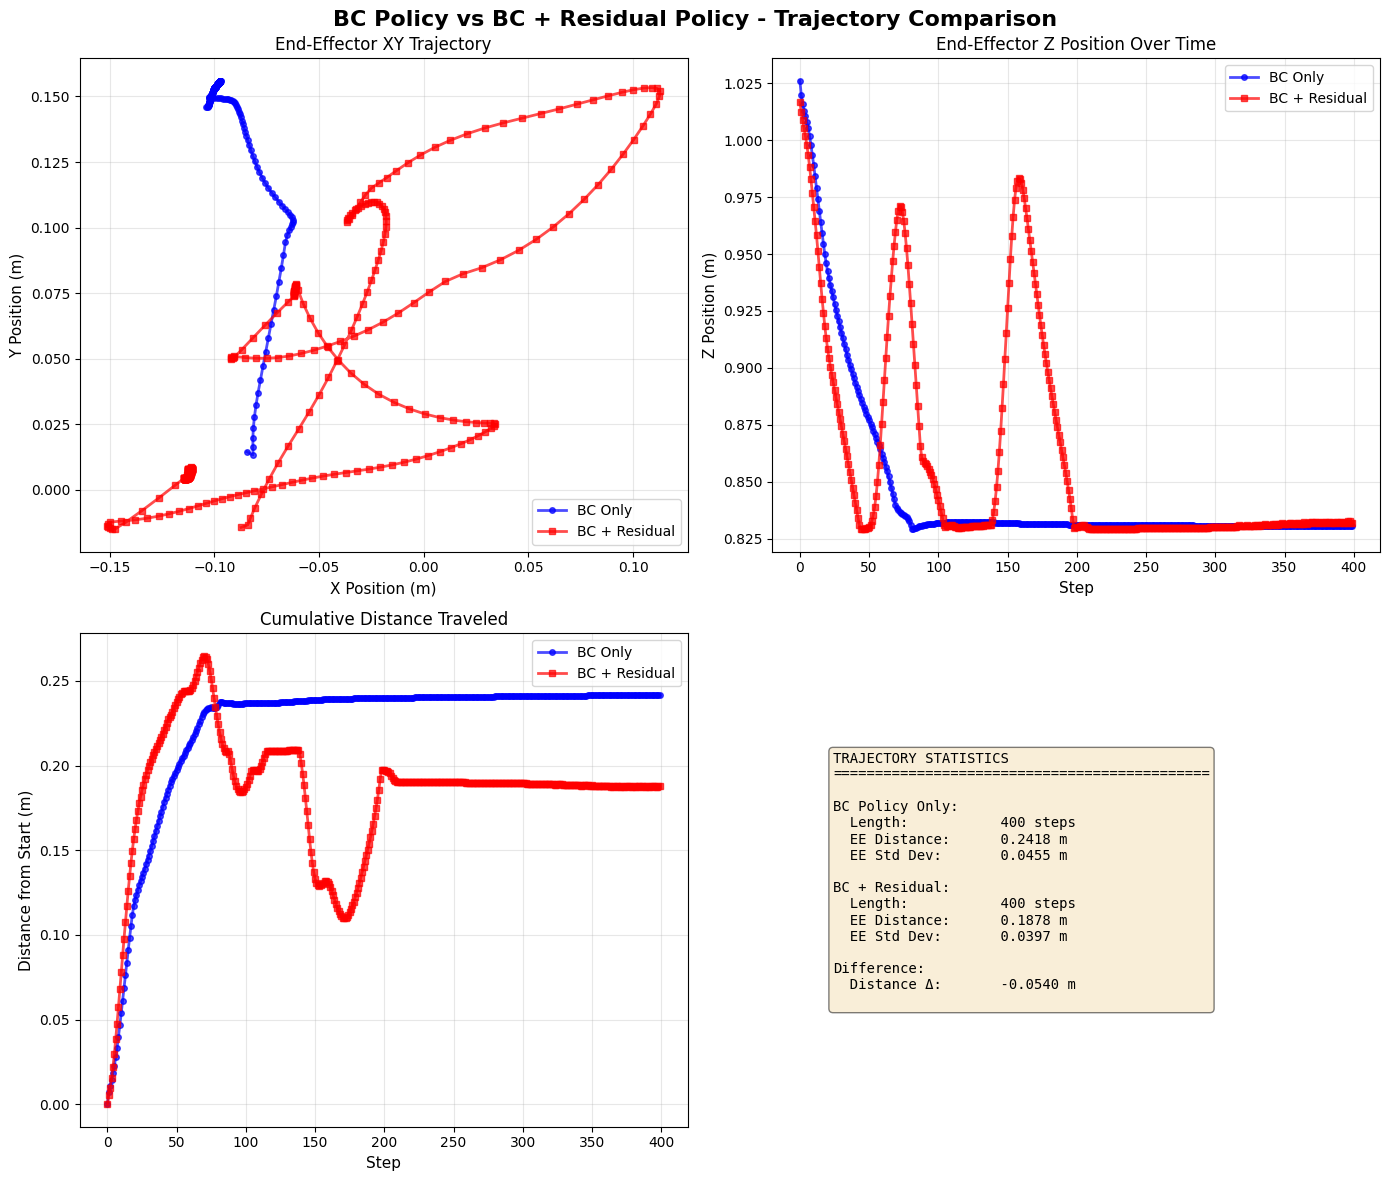


Trajectory Comparison (First Rollout):
  BC Only - Steps: 400, Final EE Distance: 0.2418m
  BC+Residual - Steps: 400, Final EE Distance: 0.1878m


In [11]:
# Visualize and compare trajectories
print("\nVisualizing trajectories...")

if results['bc_only']['trajectories'] and results['bc_residual']['trajectories']:
    # Compare first rollout from each
    bc_traj = results['bc_only']['trajectories'][0]
    bc_res_traj = results['bc_residual']['trajectories'][0]
    
    # Extract end-effector positions
    bc_eef_positions = np.array([point['obs']['robot0_eef_pos'] for point in bc_traj if 'robot0_eef_pos' in point['obs']])
    bc_res_eef_positions = np.array([point['obs']['robot0_eef_pos'] for point in bc_res_traj if 'robot0_eef_pos' in point['obs']])
    
    # Create comparison visualizations
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle('BC Policy vs BC + Residual Policy - Trajectory Comparison', fontsize=16, fontweight='bold')
    
    # 1. End-effector XY position
    ax = axes[0, 0]
    if len(bc_eef_positions) > 0:
        ax.plot(bc_eef_positions[:, 0], bc_eef_positions[:, 1], 'b-', linewidth=2, label='BC Only', marker='o', markersize=4, alpha=0.7)
    if len(bc_res_eef_positions) > 0:
        ax.plot(bc_res_eef_positions[:, 0], bc_res_eef_positions[:, 1], 'r-', linewidth=2, label='BC + Residual', marker='s', markersize=4, alpha=0.7)
    ax.set_xlabel('X Position (m)', fontsize=11)
    ax.set_ylabel('Y Position (m)', fontsize=11)
    ax.set_title('End-Effector XY Trajectory', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 2. End-effector Z position over time
    ax = axes[0, 1]
    ax.plot(bc_eef_positions[:, 2], 'b-', linewidth=2, label='BC Only', marker='o', markersize=4, alpha=0.7)
    ax.plot(bc_res_eef_positions[:, 2], 'r-', linewidth=2, label='BC + Residual', marker='s', markersize=4, alpha=0.7)
    ax.set_xlabel('Step', fontsize=11)
    ax.set_ylabel('Z Position (m)', fontsize=11)
    ax.set_title('End-Effector Z Position Over Time', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 3. Trajectory distance from start
    ax = axes[1, 0]
    bc_distances = np.linalg.norm(bc_eef_positions - bc_eef_positions[0], axis=1)
    bc_res_distances = np.linalg.norm(bc_res_eef_positions - bc_res_eef_positions[0], axis=1)
    ax.plot(bc_distances, 'b-', linewidth=2, label='BC Only', marker='o', markersize=4, alpha=0.7)
    ax.plot(bc_res_distances, 'r-', linewidth=2, label='BC + Residual', marker='s', markersize=4, alpha=0.7)
    ax.set_xlabel('Step', fontsize=11)
    ax.set_ylabel('Distance from Start (m)', fontsize=11)
    ax.set_title('Cumulative Distance Traveled', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # 4. Summary statistics
    ax = axes[1, 1]
    ax.axis('off')
    
    summary_text = "TRAJECTORY STATISTICS\n" + "="*45 + "\n\n"
    summary_text += "BC Policy Only:\n"
    summary_text += f"  Length:           {len(bc_traj)} steps\n"
    summary_text += f"  EE Distance:      {bc_distances[-1]:.4f} m\n"
    summary_text += f"  EE Std Dev:       {np.std(bc_distances):.4f} m\n\n"
    
    summary_text += "BC + Residual:\n"
    summary_text += f"  Length:           {len(bc_res_traj)} steps\n"
    summary_text += f"  EE Distance:      {bc_res_distances[-1]:.4f} m\n"
    summary_text += f"  EE Std Dev:       {np.std(bc_res_distances):.4f} m\n\n"
    
    summary_text += "Difference:\n"
    dist_diff = bc_res_distances[-1] - bc_distances[-1]
    summary_text += f"  Distance Δ:       {dist_diff:+.4f} m\n"
    
    ax.text(0.1, 0.5, summary_text, fontsize=10, family='monospace', verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print(f"\nTrajectory Comparison (First Rollout):")
    print(f"  BC Only - Steps: {len(bc_traj)}, Final EE Distance: {bc_distances[-1]:.4f}m")
    print(f"  BC+Residual - Steps: {len(bc_res_traj)}, Final EE Distance: {bc_res_distances[-1]:.4f}m")

elif results['bc_only']['trajectories']:
    print("BC trajectories available but BC+Residual trajectories missing. Cannot compare.")
else:
    print("No trajectories recorded for visualization.")



Visualizing gated residual diagnostics...


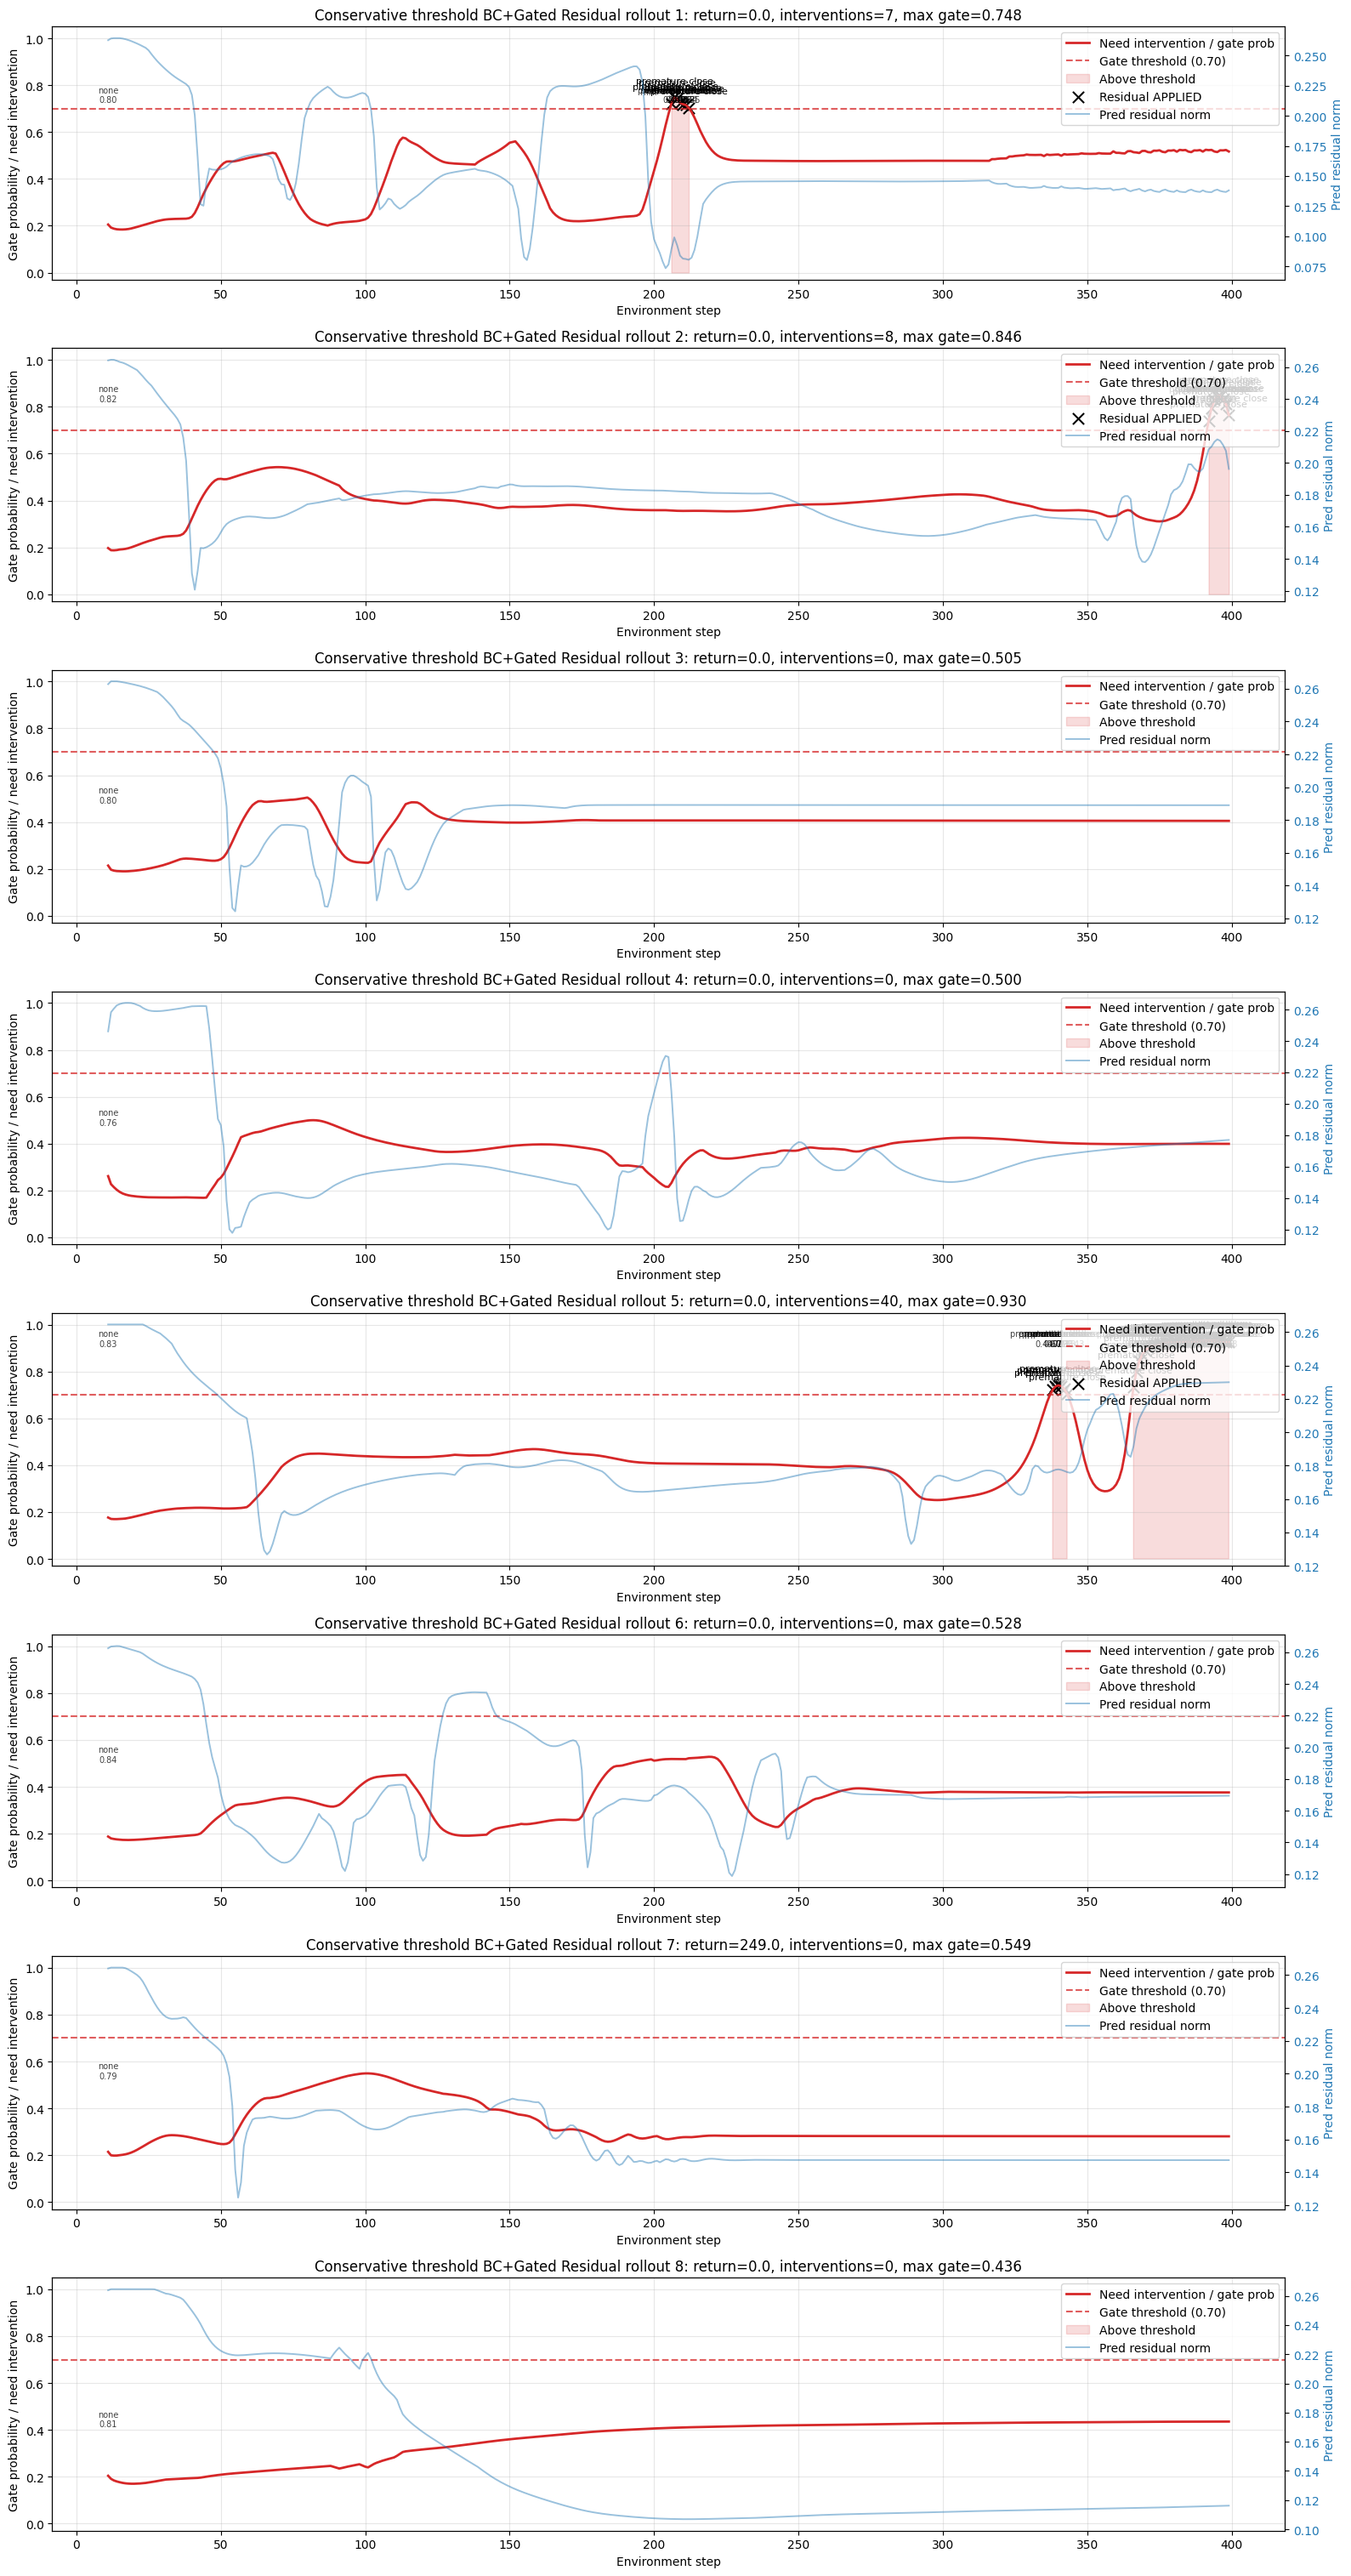

,rollout,return,max_gate,mean_gate,interventions,top_failure_at_max_gate,step_at_max_gate
0,1,0.0,0.748269,0.430181,7,premature_gripper_close,207
1,2,0.0,0.845833,0.393904,8,premature_gripper_close,396
2,3,0.0,0.504759,0.384979,0,no_failure,80
3,4,0.0,0.500169,0.369126,0,no_failure,82
4,5,0.0,0.929774,0.427700,40,premature_gripper_close,392
5,6,0.0,0.528032,0.344401,0,no_failure,219
6,7,249.0,0.549354,0.327217,0,no_failure,101
7,8,0.0,0.435802,0.357726,0,no_failure,399


In [12]:
# Visualize gate, predicted failure type, and intervention decisions over time.
print("\nVisualizing gated residual diagnostics...")

FAILURE_LABELS_SHORT = {
    'no_failure': 'none',
    'underreach_idle_before_max_reach': 'underreach',
    'premature_gripper_close': 'premature close',
    'lateral_drift': 'lateral drift',
    'premature_gripper_open': 'premature open',
}


def plot_gated_diagnostics(diagnostics_list, returns, title_prefix='BC+Gated Residual'):
    if not diagnostics_list:
        print('No gated residual diagnostics available. Run the benchmark cell first.')
        return pd.DataFrame()

    fig, axes = plt.subplots(len(diagnostics_list), 1, figsize=(16, 3.8 * len(diagnostics_list)), squeeze=False)
    axes = axes[:, 0]

    rows = []
    for rollout_idx, diagnostics in enumerate(diagnostics_list):
        ax = axes[rollout_idx]
        steps = np.asarray(diagnostics.get('steps', []), dtype=int)
        gate_probs = np.asarray(diagnostics.get('gate_probs', []), dtype=float)
        residual_norms = np.asarray(diagnostics.get('residual_norms', []), dtype=float)
        failure_names = diagnostics.get('failure_type_names', [])
        failure_confidences = np.asarray(diagnostics.get('failure_confidences', []), dtype=float)
        applied = np.asarray(diagnostics.get('applied_interventions', []), dtype=bool)
        threshold = float(diagnostics.get('gate_threshold', 0.7))
        ret = returns[rollout_idx] if rollout_idx < len(returns) else float('nan')

        if len(steps) == 0:
            ax.text(0.5, 0.5, 'No gated diagnostics recorded for this rollout', ha='center', va='center', transform=ax.transAxes)
            rows.append({'rollout': rollout_idx + 1, 'return': ret, 'max_gate': 0.0, 'mean_gate': 0.0, 'interventions': 0, 'top_failure_at_max_gate': 'none', 'step_at_max_gate': None})
            continue

        ax.plot(steps, gate_probs, color='tab:red', linewidth=2, label='Need intervention / gate prob')
        ax.axhline(threshold, color='tab:red', linestyle='--', alpha=0.75, label=f'Gate threshold ({threshold:.2f})')
        ax.fill_between(steps, 0, gate_probs, where=gate_probs >= threshold, color='tab:red', alpha=0.16, label='Above threshold')

        if applied.any():
            ax.scatter(steps[applied], gate_probs[applied], color='black', marker='x', s=90, label='Residual APPLIED')
            for step, gate, name in zip(steps[applied], gate_probs[applied], np.asarray(failure_names, dtype=object)[applied]):
                ax.annotate(
                    FAILURE_LABELS_SHORT.get(str(name), str(name)),
                    xy=(step, gate),
                    xytext=(0, 12),
                    textcoords='offset points',
                    ha='center',
                    fontsize=8,
                    arrowprops=dict(arrowstyle='->', alpha=0.45),
                )

        ax2 = ax.twinx()
        ax2.plot(steps, residual_norms, color='tab:blue', alpha=0.45, linewidth=1.4, label='Pred residual norm')
        ax2.set_ylabel('Pred residual norm', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')

        # Light labels at failure-class changes and at high-gate moments.
        last_label = None
        label_y = min(0.98, max(0.08, float(np.nanmax(gate_probs)) + 0.05))
        for i, (step, name, conf) in enumerate(zip(steps, failure_names, failure_confidences)):
            short = FAILURE_LABELS_SHORT.get(str(name), str(name))
            if short != last_label or gate_probs[i] >= threshold:
                ax.text(step, label_y, f'{short}\n{conf:.2f}', fontsize=7, ha='center', va='top', alpha=0.75)
                last_label = short

        top_idx = int(np.argmax(gate_probs))
        rows.append({
            'rollout': rollout_idx + 1,
            'return': ret,
            'max_gate': float(np.max(gate_probs)),
            'mean_gate': float(np.mean(gate_probs)),
            'interventions': int(applied.sum()),
            'top_failure_at_max_gate': failure_names[top_idx] if top_idx < len(failure_names) else 'unknown',
            'step_at_max_gate': int(steps[top_idx]),
        })

        ax.set_title(f"{title_prefix} rollout {rollout_idx + 1}: return={ret:.1f}, interventions={int(applied.sum())}, max gate={np.max(gate_probs):.3f}")
        ax.set_xlabel('Environment step')
        ax.set_ylabel('Gate probability / need intervention')
        ax.set_ylim(-0.03, 1.05)
        ax.grid(True, alpha=0.3)
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper right')

    plt.tight_layout()
    plt.show()
    df = pd.DataFrame(rows)
    display(df)
    return df

conservative_diag_df = plot_gated_diagnostics(
    results['bc_residual'].get('diagnostics', []),
    results['bc_residual'].get('returns', []),
    title_prefix='Conservative threshold BC+Gated Residual',
)



SENSITIVE GATE DIAGNOSTIC RUN: threshold=0.40
This is intentionally more aggressive than the conservative threshold and is for debugging when/what the residual wants to correct.
Sensitive rollout 1/5... 

Return: 274.0000, Success: False, Interventions: 88, Mean gate: 0.3442, Max gate: 0.9779
Sensitive rollout 2/5... 

Return: 267.0000, Success: False, Interventions: 59, Mean gate: 0.3143, Max gate: 0.5546
Sensitive rollout 3/5... 

Return: 220.0000, Success: False, Interventions: 69, Mean gate: 0.3039, Max gate: 0.5576
Sensitive rollout 4/5... 

Return: 0.0000, Success: False, Interventions: 102, Mean gate: 0.3726, Max gate: 0.5167
Sensitive rollout 5/5... 

Return: 0.0000, Success: False, Interventions: 185, Mean gate: 0.4083, Max gate: 0.9088


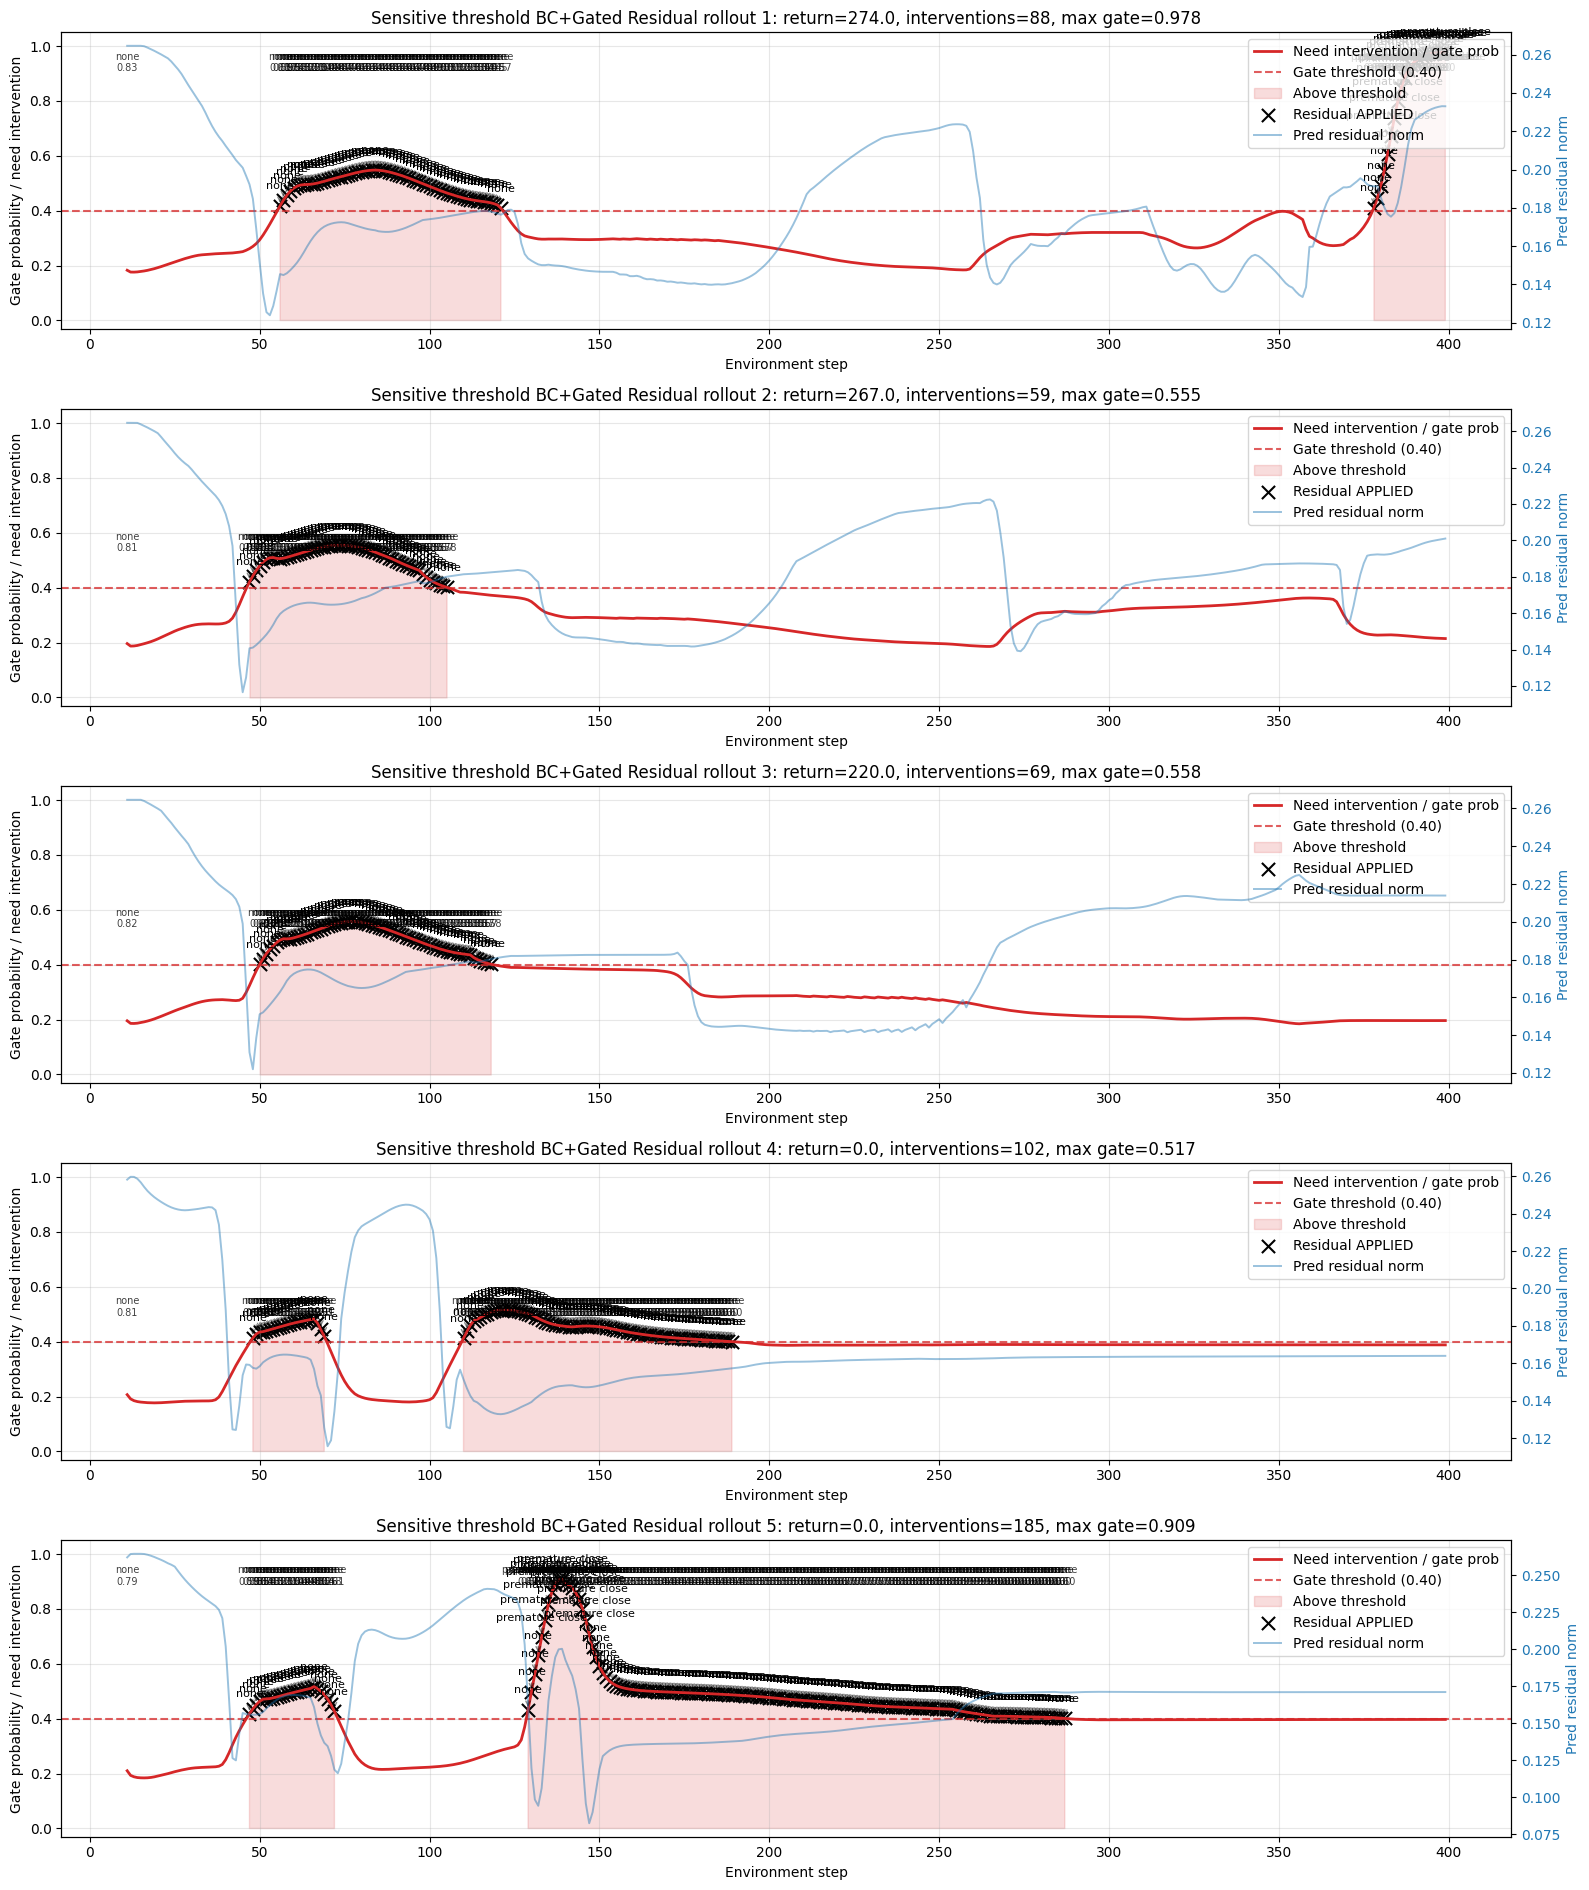

,rollout,return,max_gate,mean_gate,interventions,top_failure_at_max_gate,step_at_max_gate
0,1,274.0,0.977879,0.344228,88,premature_gripper_close,399
1,2,267.0,0.554613,0.314297,59,no_failure,74
2,3,220.0,0.557649,0.303872,69,no_failure,77
3,4,0.0,0.516732,0.372615,102,no_failure,122
4,5,0.0,0.908779,0.408328,185,premature_gripper_close,139


In [13]:
# Extra diagnostic rollouts with a lower gate threshold so we can inspect actual interventions.
print("\n" + "="*70)
print("SENSITIVE GATE DIAGNOSTIC RUN: threshold=0.40")
print("="*70)
print("This is intentionally more aggressive than the conservative threshold and is for debugging when/what the residual wants to correct.")

sensitive_results = {
    'returns': [],
    'trajectories': [],
    'successes': 0,
    'diagnostics': [],
    'videos': [],
}

if bc_policy is not None and residual_policy is not None and 'env' in globals() and env is not None:
    sensitive_policy = GatedComposedPolicy(
        bc_policy,
        residual_policy,
        device=device,
        residual_weight=0.1,
        clamp_residual=0.1,
        gate_threshold=0.40,
    )
    video_dir = Path(os.getcwd()) / 'evaluation_videos'
    sensitive_rollouts = 5
    for rollout_idx in range(sensitive_rollouts):
        print(f"Sensitive rollout {rollout_idx + 1}/{sensitive_rollouts}...", end=" ")
        video_path = video_dir / f'bc_gated_residual_sensitive_rollout_{rollout_idx + 1}.mp4' if rollout_idx < 2 else None
        result = run_rollout_with_trajectory(sensitive_policy, env, horizon=400, video_path=video_path)
        diagnostics = sensitive_policy.get_diagnostics()
        sensitive_results['returns'].append(result['total_reward'])
        sensitive_results['trajectories'].append(result['trajectory'])
        sensitive_results['diagnostics'].append(diagnostics)
        if result.get('video_path'):
            sensitive_results['videos'].append(result['video_path'])
        if result['success']:
            sensitive_results['successes'] += 1
        print(
            f"Return: {result['total_reward']:.4f}, Success: {result['success']}, "
            f"Interventions: {diagnostics['interventions']}, "
            f"Mean gate: {diagnostics['mean_gate_prob']:.4f}, "
            f"Max gate: {diagnostics['max_gate_prob']:.4f}"
        )

    sensitive_diag_df = plot_gated_diagnostics(
        sensitive_results['diagnostics'],
        sensitive_results['returns'],
        title_prefix='Sensitive threshold BC+Gated Residual',
    )

    sensitive_video_blocks = []
    for i, video_path in enumerate(sensitive_results.get('videos', []), start=1):
        sensitive_video_blocks.append(_video_html(video_path, f'Sensitive BC+Gated Residual rollout {i}'))
    if sensitive_video_blocks:
        display(HTML("<div style='display:flex; flex-wrap:wrap; gap:16px;'>" + "".join(sensitive_video_blocks) + "</div>"))
else:
    print('Skipping sensitive gate run because bc_policy, residual_policy, or env is unavailable.')


## Performance Comparison: Metrics & Statistics


/home/griffing52/tmp/ipykernel_836517/4172474349.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([bc_returns, bc_res_returns], labels=['BC Only', 'BC+Residual'], patch_artist=True)
/home/griffing52/tmp/ipykernel_836517/4172474349.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([bc_returns, bc_res_returns], labels=['BC Only', 'BC+Residual'], patch_artist=True)


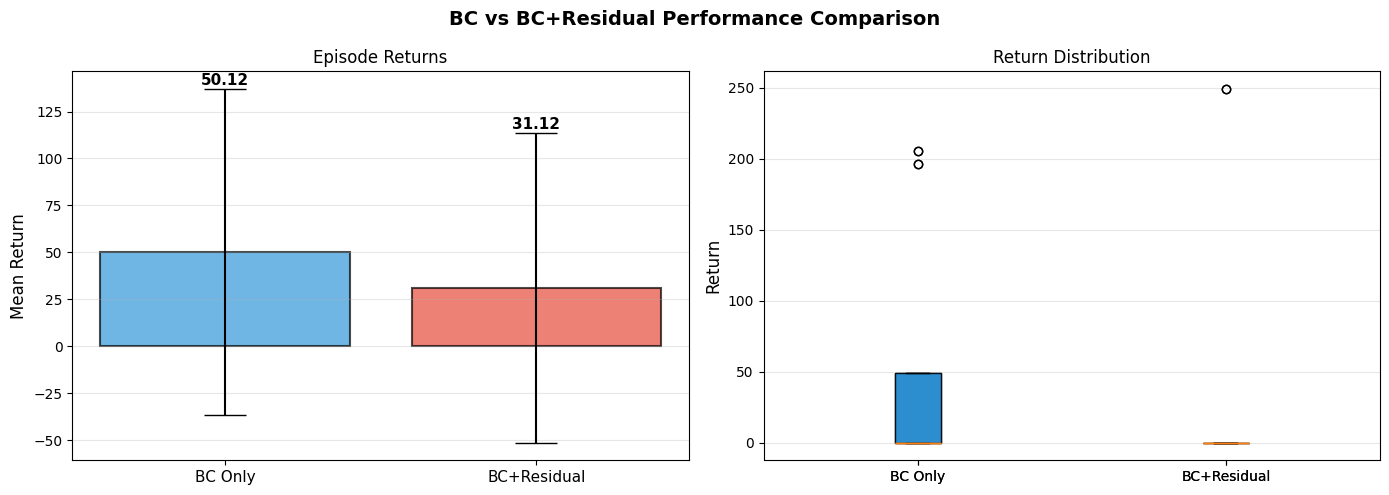


DETAILED PERFORMANCE COMPARISON

BC Policy Only:
  Mean:      50.1250
  Median:     0.0000
  Std:       86.8482
  Min/Max:    0.0000 / 205.0000

BC + Residual:
  Mean:      31.1250
  Median:     0.0000
  Std:       82.3490
  Min/Max:    0.0000 / 249.0000

Comparison:
  Mean Difference:  -19.0000 (-37.91%)
  Std Improvement:   +4.4992

Conclusion: ✗ Residual policy decreases performance by 37.9%


In [14]:
# Performance metrics and visualization
if results['bc_only']['returns'] and results['bc_residual']['returns']:
    bc_returns = np.array(results['bc_only']['returns'])
    bc_res_returns = np.array(results['bc_residual']['returns'])
    
    # Create performance comparison figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('BC vs BC+Residual Performance Comparison', fontsize=14, fontweight='bold')
    
    # 1. Return comparison
    ax = axes[0]
    x_pos = np.arange(2)
    means = [np.mean(bc_returns), np.mean(bc_res_returns)]
    stds = [np.std(bc_returns), np.std(bc_res_returns)]
    colors = ['#3498db', '#e74c3c']
    bars = ax.bar(x_pos, means, yerr=stds, capsize=15, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Mean Return', fontsize=12)
    ax.set_title('Episode Returns', fontsize=12)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(['BC Only', 'BC+Residual'], fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (mean, std) in enumerate(zip(means, stds)):
        ax.text(i, mean + std + 0.5, f'{mean:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # 2. Rollout returns distribution
    ax = axes[1]
    ax.boxplot([bc_returns, bc_res_returns], labels=['BC Only', 'BC+Residual'], patch_artist=True)
    bp = ax.boxplot([bc_returns, bc_res_returns], labels=['BC Only', 'BC+Residual'], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_ylabel('Return', fontsize=12)
    ax.set_title('Return Distribution', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed stats
    print("\n" + "="*70)
    print("DETAILED PERFORMANCE COMPARISON")
    print("="*70)
    print(f"\nBC Policy Only:")
    print(f"  Mean:     {np.mean(bc_returns):8.4f}")
    print(f"  Median:   {np.median(bc_returns):8.4f}")
    print(f"  Std:      {np.std(bc_returns):8.4f}")
    print(f"  Min/Max:  {np.min(bc_returns):8.4f} / {np.max(bc_returns):8.4f}")
    
    print(f"\nBC + Residual:")
    print(f"  Mean:     {np.mean(bc_res_returns):8.4f}")
    print(f"  Median:   {np.median(bc_res_returns):8.4f}")
    print(f"  Std:      {np.std(bc_res_returns):8.4f}")
    print(f"  Min/Max:  {np.min(bc_res_returns):8.4f} / {np.max(bc_res_returns):8.4f}")
    
    # Statistical comparison
    mean_diff = np.mean(bc_res_returns) - np.mean(bc_returns)
    pct_improvement = None if abs(np.mean(bc_returns)) < 1e-6 else (mean_diff / abs(np.mean(bc_returns))) * 100
    
    print(f"\nComparison:")
    if pct_improvement is None:
        print(f"  Mean Difference:  {mean_diff:+8.4f} (percent undefined; BC mean is ~0)")
    else:
        print(f"  Mean Difference:  {mean_diff:+8.4f} ({pct_improvement:+.2f}%)")
    print(f"  Std Improvement:  {np.std(bc_returns) - np.std(bc_res_returns):+8.4f}")
    print(f"\nConclusion: ", end="")
    if pct_improvement is None:
        print(f"~ Percent comparison undefined because BC mean is ~0; mean difference is {mean_diff:+.4f}")
    elif pct_improvement > 5:
        print(f"✓ Residual policy improves performance by {pct_improvement:.1f}%")
    elif pct_improvement < -5:
        print(f"✗ Residual policy decreases performance by {-pct_improvement:.1f}%")
    else:
        print(f"~ Residual policy has similar performance (Δ {pct_improvement:+.1f}%)")

elif results['bc_only']['returns']:
    print("BC policy results available but BC+Residual results missing.")
else:
    print("No results available for comparison.")


## Results Export & Conclusions

Summary of BC vs BC+Residual benchmark evaluation and next steps.


In [15]:
# Export results summary
print("\n" + "="*70)
print("FINAL CONCLUSIONS")
print("="*70)

summary = {
    'evaluation_date': pd.Timestamp.now().isoformat(),
    'bc_policy': str(BC_CHECKPOINT) if 'BC_CHECKPOINT' in globals() else 'Not evaluated',
    'residual_policy': str(RESIDUAL_CHECKPOINT),
    'num_rollouts': len(results.get('bc_only', {}).get('returns', [])),
}

if results['bc_only']['returns'] and results['bc_residual']['returns']:
    bc_returns = np.array(results['bc_only']['returns'])
    bc_res_returns = np.array(results['bc_residual']['returns'])
    
    summary.update({
        'bc_mean_return': float(np.mean(bc_returns)),
        'bc_std_return': float(np.std(bc_returns)),
        'bc_success_rate': results['bc_only']['successes'] / len(bc_returns),
        'bc_residual_mean_return': float(np.mean(bc_res_returns)),
        'bc_residual_std_return': float(np.std(bc_res_returns)),
        'bc_residual_success_rate': results['bc_residual']['successes'] / len(bc_res_returns),
        'return_difference': float(np.mean(bc_res_returns) - np.mean(bc_returns)),
        'improvement_pct': None if abs(np.mean(bc_returns)) < 1e-6 else float((np.mean(bc_res_returns) - np.mean(bc_returns)) / abs(np.mean(bc_returns)) * 100),
    })
    
    print(f"\n✓ Successfully evaluated BC vs BC+Residual composition")
    print(f"  BC Mean Return:           {summary['bc_mean_return']:.4f} ± {summary['bc_std_return']:.4f}")
    print(f"  BC+Residual Mean Return:  {summary['bc_residual_mean_return']:.4f} ± {summary['bc_residual_std_return']:.4f}")
    if summary['improvement_pct'] is None:
        print(f"  Return Difference:        {summary['return_difference']:+.4f} (percent undefined; BC mean is ~0)")
    else:
        print(f"  Improvement:              {summary['improvement_pct']:+.2f}%")
    
elif results['bc_only']['returns']:
    print(f"\n⚠ BC policy evaluated but BC+Residual composition failed or not available")
    bc_returns = np.array(results['bc_only']['returns'])
    summary['bc_mean_return'] = float(np.mean(bc_returns))
    summary['bc_std_return'] = float(np.std(bc_returns))
else:
    print(f"\n✗ Evaluation incomplete - no results to export")

print(f"\n✓ Evaluation complete. Results stored in 'results' dict.")
print(f"\nKey Findings:")
print(f"  - Composition formula: a_exec = a_bc + residual_weight * gate_prob * clipped_residual when gate >= threshold")
print(f"  - Residual policy requires 12-step history (first 12 steps use base policy only)")
print(f"  - Trajectory visualizations saved above")



FINAL CONCLUSIONS

✓ Successfully evaluated BC vs BC+Residual composition
  BC Mean Return:           50.1250 ± 86.8482
  BC+Residual Mean Return:  31.1250 ± 82.3490
  Improvement:              -37.91%

✓ Evaluation complete. Results stored in 'results' dict.

Key Findings:
  - Composition formula: a_exec = a_bc + residual_weight * gate_prob * clipped_residual when gate >= threshold
  - Residual policy requires 12-step history (first 12 steps use base policy only)
  - Trajectory visualizations saved above


## Next Steps: Full Rollout Evaluation

For more comprehensive policy evaluation with full environment interaction, use robomimic's evaluation scripts:

```bash
# Run 50 rollouts with video rendering
python run_trained_agent.py --agent /path/to/model.pth \
    --n_rollouts 50 --horizon 400 --seed 0 \
    --video_path /path/to/output.mp4 \
    --camera_names agentview robot0_eye_in_hand

# Write rollouts to HDF5 dataset
python run_trained_agent.py --agent /path/to/model.pth \
    --n_rollouts 50 --horizon 400 --seed 0 \
    --dataset_path /path/to/output.hdf5 --dataset_obs
```

**This notebook focused on:**
- Residual policy recovery quality (how well it predicts corrective actions)
- Comparison across different base policies (BC vs Diffusion)

**For full evaluation, also consider:**
- Task success rates in the environment
- Recovery success under different perturbation types and severities
- Comparison to baselines (no recovery, oracle recovery)
- Statistical significance testing

## Next Steps

**Current Benchmark**: BC vs BC+Residual composition

**Evaluation Framework Ready For**:
1. **Perturbed Trajectory Evaluation**: Apply synthetic perturbations (LATERAL_DRIFT, UNDERREACH_IDLE, etc.) and measure recovery
2. **Diffusion Policy Integration**: Extend to Diffusion+Residual composition
3. **Multi-Policy Comparison**: BC vs Diffusion vs BC+Residual vs Diffusion+Residual
4. **Trajectory Distribution Analysis**: Visualize policy diversity and robustness

**Architecture Notes**:
- Residual policy input: (B, 12, 74) = 12-step history of states (74-dim each)
- Residual policy output: (B, 30, 7) = 30-step horizon of action corrections
- Composition: `a_executed = clip(a_base + residuals[:, 0])`  (first timestep of residual window)
- History warmup: First 12 steps of episode use base policy only

**To Extend to Diffusion Policy**:
1. Create `ComposedDiffusionPolicy` wrapper similar to `ComposedBC_Residual`
2. Run parallel rollouts with `ComposedPolicy(diffusion, residual)`
3. Compare: BC+Residual vs Diffusion+Residual


## Important Note: Training vs Evaluation Paradigm

**Key Insight**: Your residual policy was trained to **recover from perturbations**, not to improve clean BC execution.

Training data: `nominal_traj → apply_perturbation → learn residuals = nominal_actions - perturbed_actions`

Evaluation should be: `nominal_traj → apply_perturbation → apply_BC → add_residual_corrections`

**Current Issue**: Applying residual to clean BC trajectories causes full cancellation (residual=-base_action when no disturbance).

**Next Steps**:
1. Test residual policy on **perturbed trajectories** to validate recovery capability
2. OR retrain residual policy on BC execution trajectories to improve nominal performance
3. Create two evaluation modes:
   - **Recovery Mode**: Apply perturbation, then measure if residual helps recovery
   - **Improvement Mode**: Directly measure if residual improves BC performance


In [16]:
## Perturbed Trajectory Evaluation: Follow-up

print("\n" + "="*70)
print("PERTURBED TRAJECTORY EVALUATION SKIPPED FOR QUICK SANITY")
print("="*70)
print("The old cell attempted perturb_gen.apply(action=...), but PerturbationGenerator has no action-level apply method.")
print("This quick sanity pass intentionally evaluates clean BC vs clean BC+gated residual only.")
print("Next step: add a real online action/state perturbation wrapper before testing recovery under injected disturbances.")



PERTURBED TRAJECTORY EVALUATION SKIPPED FOR QUICK SANITY
The old cell attempted perturb_gen.apply(action=...), but PerturbationGenerator has no action-level apply method.
This quick sanity pass intentionally evaluates clean BC vs clean BC+gated residual only.
Next step: add a real online action/state perturbation wrapper before testing recovery under injected disturbances.


## Diagnosis: Why BC+Residual Gets 0 Return

### The Problem
Your residual policy was **trained to correct perturbations**, not to improve nominal BC performance:
- **Training**: Learn `Δa = a_nominal - a_perturbed` from perturbed trajectories
- **What we tried**: Apply residual to clean BC trajectories → residual ≈ -a_bc → a_exec ≈ 0

### Solutions

**Option A: Test on Perturbed Trajectories (RECOMMENDED)**
- Run perturbed trajectory evaluation above to validate residual recovery works
- If recovery is successful: Your residual policy is working correctly!
- If recovery fails: Check if perturbation types/magnitudes match training data

**Option B: Retrain Residual for BC Improvement**  
- Current residual: Trained on `[perturbed_state, perturbed_action] → correction`
- Needed residual: `[nominal_bc_state, nominal_bc_action] → minor_improvement`
- Requires retraining on BC execution data with small corrections

**Option C: Use Residual as Intended**
- Residual policy should only be applied **after perturbation detection**
- Architecture: `if disturbance_detected → apply_residual` else `use_bc_only`

### Recommended Next Step
Run the **Perturbed Trajectory Evaluation** cell above to confirm your residual policy actually recovers from the same perturbations it was trained on.
